# TASK6 智能决策者：用机器学习定制专属策略

## Goal

本 Notebook 是 TASK6 的教学型审计伴随文件。它读取脚本生成的季度面板、模型指标和回测结果，复核核心计算并展示关键图形。

## Setup

### Key Assumptions

- 股票池为抓取日的中证 300 当前成分股，存在幸存者偏差。
- 因子在季度末形成，标签为下一季度首个交易日开盘到再下一季度首个交易日开盘的收益。
- 测试期逐季度扩展窗口重训；主策略每季度等权持有预测前 30。
- 净收益按组合换手率乘以单边 0.2% 综合成本扣减。

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
TASK_DIR = ROOT / 'TASK6' if (ROOT / 'TASK6').exists() else ROOT
OUTPUT_DIR = TASK_DIR / 'outputs'
PANEL_PATH = TASK_DIR / 'data' / 'processed' / 'quarterly_panel.csv'
assert OUTPUT_DIR.exists() and PANEL_PATH.exists()
plt.style.use('seaborn-v0_8-whitegrid')

## Steps

### 1. Load and validate the quarterly panel

In [2]:
panel = pd.read_csv(PANEL_PATH, dtype={'ts_code': str})
quality = json.loads((OUTPUT_DIR / 'data_quality.json').read_text(encoding='utf-8'))
print({k: quality[k] for k in ['panel_rows','panel_stock_count','panel_quarters','panel_duplicate_keys']})
assert panel.duplicated(['ts_code','quarter_index']).sum() == 0
panel[['quarter','ts_code','signal_date','entry_date','exit_date','forward_return','target_rank']].head()

{'panel_rows': 4281, 'panel_stock_count': 120, 'panel_quarters': 41, 'panel_duplicate_keys': 0}


,quarter,ts_code,signal_date,entry_date,exit_date,forward_return,target_rank
0,2016Q1,000001,2016-03-31,2016-04-01,2016-07-01,-0.003648,0.455882
1,2016Q1,000063,2016-03-04,2016-04-07,2016-07-01,-0.051526,0.308824
2,2016Q1,000166,2016-03-31,2016-04-01,2016-07-01,-0.050619,0.323529
3,2016Q1,000333,2016-03-31,2016-04-01,2016-07-01,0.179390,0.882353
4,2016Q1,000425,2016-03-31,2016-04-01,2016-07-01,-0.127290,0.058824


### 2. Inspect time splits and model prediction metrics

In [3]:
split_summary = pd.read_csv(OUTPUT_DIR / 'split_summary.csv')
model_metrics = pd.read_csv(OUTPUT_DIR / 'model_metrics.csv')
display(split_summary)
display(model_metrics[['model_zh','mae_rank','rmse_rank','r2_rank','mean_rank_ic','positive_ic_ratio']])

,split,quarter_start,quarter_end,quarters,rows,stocks
0,train,2016Q1,2023Q1,29,2851,114
1,validation,2023Q2,2024Q1,4,471,119
2,test,2024Q2,2026Q1,8,959,120


,model_zh,mae_rank,rmse_rank,r2_rank,mean_rank_ic,positive_ic_ratio
0,岭回归,0.255157,0.296152,-0.052543,-0.137134,0.250
1,决策树,0.258221,0.301673,-0.092153,-0.079724,0.500
2,随机森林,0.254006,0.293384,-0.032961,-0.096805,0.375


### 3. Plot quarterly Rank IC

C:\Users\13377\AppData\Local\Temp\ipykernel_78568\3600866901.py:8: UserWarning: Glyph 20915 (\N{CJK UNIFIED IDEOGRAPH-51B3}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
C:\Users\13377\AppData\Local\Temp\ipykernel_78568\3600866901.py:8: UserWarning: Glyph 31574 (\N{CJK UNIFIED IDEOGRAPH-7B56}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
C:\Users\13377\AppData\Local\Temp\ipykernel_78568\3600866901.py:8: UserWarning: Glyph 26641 (\N{CJK UNIFIED IDEOGRAPH-6811}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
C:\Users\13377\AppData\Local\Temp\ipykernel_78568\3600866901.py:8: UserWarning: Glyph 23725 (\N{CJK UNIFIED IDEOGRAPH-5CAD}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
C:\Users\13377\AppData\Local\Temp\ipykernel_78568\3600866901.py:8: UserWarning: Glyph 22238 (\N{CJK UNIFIED IDEOGRAPH-56DE}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
C:\Users\13377\AppData\Local\Temp\ipykernel_78568\3600866901.py:8: Use

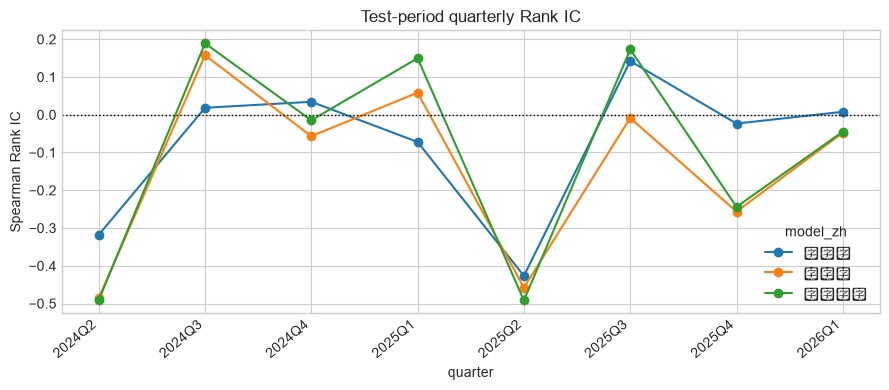

In [4]:
quarterly_ic = pd.read_csv(OUTPUT_DIR / 'quarterly_ic.csv')
pivot_ic = quarterly_ic.pivot(index='quarter', columns='model_zh', values='rank_ic')
ax = pivot_ic.plot(figsize=(9, 4), marker='o')
ax.axhline(0, color='black', linestyle=':', linewidth=1)
ax.set_title('Test-period quarterly Rank IC')
ax.set_ylabel('Spearman Rank IC')
plt.xticks(rotation=40, ha='right')
plt.tight_layout(); plt.show()

### 4. Inspect Top 30 backtest metrics

In [5]:
backtest_metrics = pd.read_csv(OUTPUT_DIR / 'backtest_metrics.csv')
quarterly_returns = pd.read_csv(OUTPUT_DIR / 'quarterly_returns.csv')
display(backtest_metrics[['model_zh','cumulative_return','annualized_return','annualized_volatility','max_drawdown','information_ratio']])

,model_zh,cumulative_return,annualized_return,annualized_volatility,max_drawdown,information_ratio
0,决策树,0.300400,0.140351,0.176175,-0.082902,-1.038928
1,随机森林,0.227182,0.107783,0.160292,-0.071350,-1.192671
2,岭回归,0.096657,0.047214,0.156873,-0.104641,-1.401037


## Checks

### 5. Independently recompute cumulative return and maximum drawdown

In [6]:
checks = []
for model, group in quarterly_returns.groupby('model'):
    group = group.sort_values('quarter_index')
    nav = (1 + group['net_return']).cumprod()
    cumulative = nav.iloc[-1] - 1
    max_drawdown = (nav / nav.cummax() - 1).min()
    saved = backtest_metrics.set_index('model').loc[model]
    checks.append({'model': model, 'cumulative_saved': saved.cumulative_return, 'cumulative_recomputed': cumulative, 'max_dd_saved': saved.max_drawdown, 'max_dd_recomputed': max_drawdown})
checks = pd.DataFrame(checks)
assert np.allclose(checks['cumulative_saved'], checks['cumulative_recomputed'])
assert np.allclose(checks['max_dd_saved'], checks['max_dd_recomputed'])
checks

,model,cumulative_saved,cumulative_recomputed,max_dd_saved,max_dd_recomputed
0,decision_tree,0.300400,0.300400,-0.082902,-0.082902
1,random_forest,0.227182,0.227182,-0.071350,-0.071350
2,ridge,0.096657,0.096657,-0.104641,-0.104641


## Next Steps

本次测试期平均 Rank IC 最佳模型为 **决策树**，平均 Rank IC 为 **-0.080**。后续最重要的改进是使用逐季度历史成分股和公告日对齐的财务因子，并完整模拟停牌、涨跌停、佣金、印花税与冲击成本。